In [1]:
import pandas as pd

In [2]:
results_lasso = pd.read_csv("../../results_loso_lasso_final/loso_features_weights.tsv", sep = '\t')

In [3]:
results_ridge = pd.read_csv("../../results_loso_ridge_final/loso_features_weights.tsv", sep = '\t')

In [4]:
results_lasso.weight.value_counts()

weight
 0.000000    279168
-0.007551         1
 0.003040         1
 0.083514         1
-0.030154         1
              ...  
-0.057041         1
-0.040711         1
-0.002004         1
 0.003461         1
-0.014334         1
Name: count, Length: 121, dtype: int64

In [5]:
results_lasso

,weight,status,test_site,feature_name
0,0.0,Kept,ds000030,corr_1_2
1,0.0,Kept,ds000030,corr_1_3
2,0.0,Kept,ds000030,corr_1_4
3,0.0,Kept,ds000030,corr_1_5
4,0.0,Kept,ds000030,corr_1_6
...,...,...,...,...
279283,0.0,Kept,ds_cobre,corr_430_433
279284,0.0,Kept,ds_cobre,corr_430_434
279285,0.0,Kept,ds_cobre,corr_432_433
279286,0.0,Kept,ds_cobre,corr_432_434


In [6]:
results_ridge

,weight,status,test_site,feature_name
0,-0.000394,Kept,ds000030,corr_1_2
1,0.000066,Kept,ds000030,corr_1_3
2,-0.000313,Kept,ds000030,corr_1_4
3,-0.000149,Kept,ds000030,corr_1_5
4,-0.000349,Kept,ds000030,corr_1_6
...,...,...,...,...
279283,0.000066,Kept,ds_cobre,corr_430_433
279284,-0.000209,Kept,ds_cobre,corr_430_434
279285,-0.000227,Kept,ds_cobre,corr_432_433
279286,-0.000061,Kept,ds_cobre,corr_432_434


In [7]:
results_ridge.test_site.value_counts()

test_site
ds000030    93096
ds004302    93096
ds_cobre    93096
Name: count, dtype: int64

Lasso shape: (279288, 4)
Ridge shape: (279288, 4)

TOP CONSENSUS : Features sélectionnées par Lasso + Validées par Ridge
Nombre de features stables (>= 2 sites Lasso) : 8
feature_name  n_sites_lasso  avg_rank_ridge  avg_weight_lasso
corr_224_227              3      137.333333         -0.073552
corr_309_344              2       51.666667         -0.072825
corr_193_426              2       78.000000          0.027243
  corr_2_264              2      773.666667         -0.016554
   corr_2_13              2     1173.333333         -0.037492
corr_173_251              2     1256.666667         -0.081127
corr_206_356              2     2160.666667         -0.033401
corr_205_426              2    17353.333333          0.053707


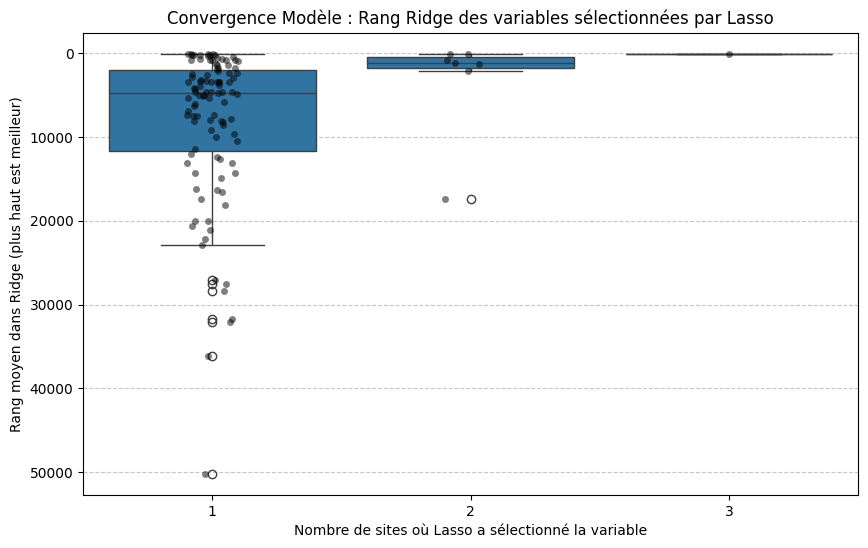


Fichier exporté : consensus_features_metrics.tsv


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CHARGEMENT ET PRÉPARATION
# ==============================================================================
# Remplace par tes chemins réels
path_lasso = "../../results_loso_lasso_final/loso_features_weights.tsv"
path_ridge = "../../results_loso_ridge_final/loso_features_weights.tsv"

df_lasso = pd.read_csv(path_lasso, sep='\t')
df_ridge = pd.read_csv(path_ridge, sep='\t')

print(f"Lasso shape: {df_lasso.shape}")
print(f"Ridge shape: {df_ridge.shape}")

# A) Traitement LASSO : On garde seulement les poids non nuls
# On prend la valeur absolue car le signe peut varier (bien que rare pour la même feature)
df_lasso['abs_weight'] = df_lasso['weight'].abs()
df_lasso_active = df_lasso[df_lasso['weight'] != 0].copy()

# B) Traitement RIDGE : On doit classer (Rank) les features par site car les échelles varient
df_ridge['abs_weight'] = df_ridge['weight'].abs()

# On calcule le rang pour chaque site (1 = le plus gros poids)
df_ridge['rank_site'] = df_ridge.groupby('test_site')['abs_weight'].rank(ascending=False)

# ==============================================================================
# 2. ANALYSE CONSENSUS INTER-SITES (STABILITÉ)
# ==============================================================================

# --- LASSO : Fréquence de sélection ---
# On compte combien de sites ont sélectionné chaque feature
lasso_counts = df_lasso_active.groupby('feature_name')['test_site'].nunique().reset_index()
lasso_counts.columns = ['feature_name', 'n_sites_lasso']

# --- RIDGE : Rang Moyen ---
# On fait la moyenne des rangs sur les 3 sites pour chaque feature
# (Plus le score est bas, plus la feature est importante stablement)
ridge_avg_rank = df_ridge.groupby('feature_name')['rank_site'].mean().reset_index()
ridge_avg_rank.columns = ['feature_name', 'avg_rank_ridge']

# ==============================================================================
# 3. FUSION ET CONSENSUS GLOBAL
# ==============================================================================

# On part des features sélectionnées au moins une fois par Lasso
df_consensus = pd.merge(lasso_counts, ridge_avg_rank, on='feature_name', how='left')

# On ajoute le poids moyen Lasso pour info
lasso_avg_w = df_lasso_active.groupby('feature_name')['weight'].mean().reset_index()
lasso_avg_w.columns = ['feature_name', 'avg_weight_lasso']
df_consensus = pd.merge(df_consensus, lasso_avg_w, on='feature_name')

# On trie : D'abord par nombre de sites Lasso (3 > 2 > 1), puis par rang Ridge (petit > grand)
df_consensus = df_consensus.sort_values(by=['n_sites_lasso', 'avg_rank_ridge'], ascending=[False, True])

# ==============================================================================
# 4. AFFICHAGE DES RÉSULTATS
# ==============================================================================

print("\n" + "="*60)
print("TOP CONSENSUS : Features sélectionnées par Lasso + Validées par Ridge")
print("="*60)
# On affiche les features trouvées dans au moins 2 sites, ou le top 10 absolu
top_features = df_consensus[df_consensus['n_sites_lasso'] >= 2]

if top_features.empty:
    print("Aucune feature commune à >= 2 sites avec Lasso.")
    print("Voici le top 10 des features sélectionnées dans 1 site, triées par rang Ridge :")
    print(df_consensus.head(10).to_string(index=False))
else:
    print(f"Nombre de features stables (>= 2 sites Lasso) : {len(top_features)}")
    print(top_features.to_string(index=False))

# ==============================================================================
# 5. VISUALISATION : VALIDATION CROISÉE
# ==============================================================================
# Est-ce que les features choisies par Lasso sont bien classées par Ridge ?

plt.figure(figsize=(10, 6))

# On prend tout le df_consensus (toutes les features Lasso non nulles)
# X = Nombre de sites Lasso, Y = Rang moyen Ridge 
sns.boxplot(data=df_consensus, x='n_sites_lasso', y='avg_rank_ridge')
sns.stripplot(data=df_consensus, x='n_sites_lasso', y='avg_rank_ridge', color='black', alpha=0.5)

plt.gca().invert_yaxis() # On inverse Y car rang 1 est "en haut" (meilleur)
plt.title("Convergence Modèle : Rang Ridge des variables sélectionnées par Lasso")
plt.xlabel("Nombre de sites où Lasso a sélectionné la variable")
plt.ylabel("Rang moyen dans Ridge (plus haut est meilleur)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Export
df_consensus.to_csv("consensus_features_metrics.tsv", sep='\t', index=False)
print("\nFichier exporté : consensus_features_metrics.tsv")

1. Chargement de l'atlas et création du mapping...
   -> Mapping créé pour 434 régions.
2. Chargement des résultats Lasso...
   -> Features Lasso totales (>=1 site) : 111
   -> Features Lasso stables (>=2 sites) : 8

FIGURE 1 : VARIABLES STABLES (CONSENSUS >= 2 SITES)

--- Liste détaillée des interactions stables ---
     Feature             Interaction
corr_173_251      Default <-> SomMot
corr_193_426  Default <-> Cerebellum
corr_205_426   Visual <-> Cerebellum
corr_206_356      Visual <-> Control
corr_224_227       SomMot <-> SomMot
   corr_2_13       Visual <-> Visual
  corr_2_264     Visual <-> DorsAttn
corr_309_344 SalVentAttn <-> Control


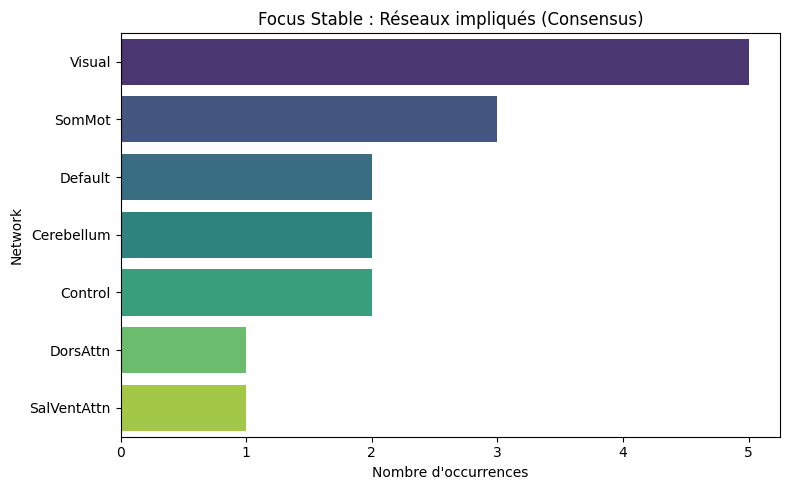


FIGURE 2 : HEATMAP GLOBALE DES INTERACTIONS


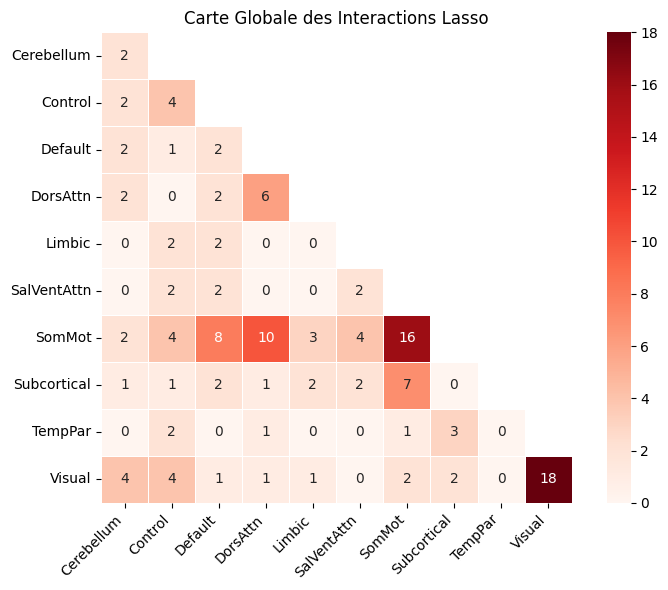


FIGURE 3 : IMPORTANCE GLOBALE DES RÉSEAUX (TOTAL LASSO)
Classement global des réseaux (Total occurences Lasso) :
    Network  Count
     SomMot     57
     Visual     33
   DorsAttn     23
    Default     22
    Control     22
Subcortical     21
 Cerebellum     15
SalVentAttn     12
     Limbic     10
    TempPar      7


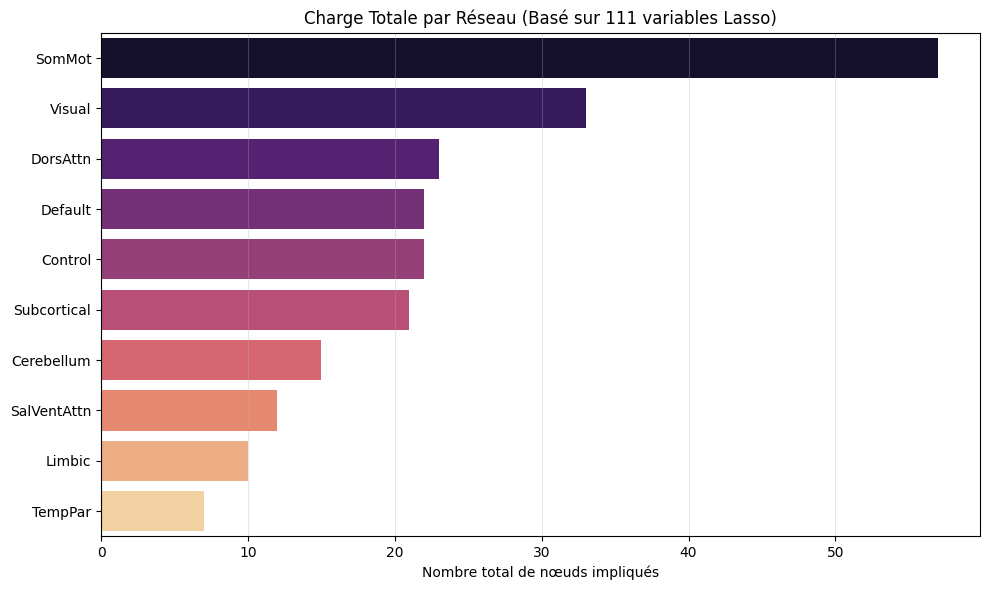


Terminé.


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# ==============================================================================
# CONFIGURATION
# ==============================================================================
path_lasso = "../../results_loso_lasso_final/loso_features_weights.tsv"
path_ridge = "../../results_loso_ridge_final/loso_features_weights.tsv"
ATLAS_TSV = "/scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.tsv"

# ==============================================================================
# 1. CHARGEMENT ET PARSING (ATLAS)
# ==============================================================================
print("1. Chargement de l'atlas et création du mapping...")

def get_network_name_precise(raw_name):
    s = str(raw_name).strip()
    if "FreeSurfer" in s: return "Subcortical"
    if "Buckner" in s: return "Cerebellum"
    
    match = re.search(r'(?:LH|RH)_([A-Za-z]+)_', s)
    if match:
        net = match.group(1)
        if "SomMot" in net: return "SomMot"
        if "Vis" in net: return "Visual"
        if "DorsAttn" in net: return "DorsAttn"
        if "SalVentAttn" in net: return "SalVentAttn"
        if "Limbic" in net: return "Limbic"
        if "Cont" in net: return "Control"
        if "Default" in net: return "Default"
        if "TempPar" in net: return "TempPar"
        return net
    return "Other"

try:
    df_atlas = pd.read_csv(ATLAS_TSV, sep='\t', header=None, dtype=str)
    # Recherche auto colonne FreeSurfer
    target_col = -1
    for col in df_atlas.columns:
        if df_atlas[col].str.contains("FreeSurfer").any():
            target_col = col
            break
    
    # Selection de la colonne
    if target_col != -1:
        raw_labels = df_atlas[target_col].tolist()
    else:
        raw_labels = df_atlas[0].tolist() # Fallback
        
    id_to_network = {i+1: get_network_name_precise(name) for i, name in enumerate(raw_labels)}
    print(f"   -> Mapping créé pour {len(id_to_network)} régions.")

except Exception as e:
    print(f"Erreur critique Atlas : {e}")
    exit()

# ==============================================================================
# 2. PRÉPARATION DES DONNÉES LASSO
# ==============================================================================
print("2. Chargement des résultats Lasso...")
df_lasso = pd.read_csv(path_lasso, sep='\t')

# On ne garde que ce qui est non-nul (sélectionné par Lasso)
df_lasso_active = df_lasso[df_lasso['weight'] != 0].copy()

# On compte dans combien de sites chaque feature apparait
lasso_counts = df_lasso_active.groupby('feature_name')['test_site'].nunique().reset_index()
lasso_counts.columns = ['feature_name', 'n_sites']

# LISTE A : Les features stables (>= 2 sites) pour l'analyse précise
stable_features = lasso_counts[lasso_counts['n_sites'] >= 2]['feature_name'].tolist()

# LISTE B : Toutes les features (>= 1 site) pour l'analyse globale
all_active_features = lasso_counts['feature_name'].tolist()

print(f"   -> Features Lasso totales (>=1 site) : {len(all_active_features)}")
print(f"   -> Features Lasso stables (>=2 sites) : {len(stable_features)}")

# ==============================================================================
# 3. FIGURE 1 : ANALYSE DES VARIABLES STABLES (Barplot + Liste)
# ==============================================================================
print("\n" + "="*80)
print("FIGURE 1 : VARIABLES STABLES (CONSENSUS >= 2 SITES)")
print("="*80)

stable_network_counts = {}
stable_interactions = []

for feat in stable_features:
    try:
        parts = feat.split('_')
        idx_a, idx_b = int(parts[1]), int(parts[2])
        net_a = id_to_network.get(idx_a, "Unknown")
        net_b = id_to_network.get(idx_b, "Unknown")
        
        # Compte des Nœuds
        stable_network_counts[net_a] = stable_network_counts.get(net_a, 0) + 1
        stable_network_counts[net_b] = stable_network_counts.get(net_b, 0) + 1
        
        stable_interactions.append({'Feature': feat, 'Interaction': f"{net_a} <-> {net_b}"})
    except: continue

# A. Affichage Texte
print("\n--- Liste détaillée des interactions stables ---")
print(pd.DataFrame(stable_interactions).to_string(index=False) if stable_interactions else "Aucune.")

# B. Barplot Stable
df_stable_nodes = pd.DataFrame(list(stable_network_counts.items()), columns=['Network', 'Count'])
df_stable_nodes = df_stable_nodes.sort_values('Count', ascending=False)

if not df_stable_nodes.empty:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_stable_nodes, x='Count', y='Network', hue='Network', palette='viridis', legend=False)
    plt.title("Focus Stable : Réseaux impliqués (Consensus)")
    plt.xlabel("Nombre d'occurrences")
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 4. FIGURE 2 : HEATMAP GLOBALE (INTERACTIONS)
# ==============================================================================
print("\n" + "="*80)
print("FIGURE 2 : HEATMAP GLOBALE DES INTERACTIONS")
print("="*80)

all_networks = sorted(list(set(id_to_network.values())))
if "Unknown" in all_networks: all_networks.remove("Unknown")
if "Other" in all_networks: all_networks.remove("Other")

lasso_matrix = pd.DataFrame(0, index=all_networks, columns=all_networks)

for feat in all_active_features:
    try:
        parts = feat.split('_')
        idx_a, idx_b = int(parts[1]), int(parts[2])
        net_a = id_to_network.get(idx_a, "Other")
        net_b = id_to_network.get(idx_b, "Other")
        
        if net_a in lasso_matrix.index and net_b in lasso_matrix.columns:
            lasso_matrix.loc[net_a, net_b] += 1
            lasso_matrix.loc[net_b, net_a] += 1
    except: continue

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(lasso_matrix, dtype=bool), k=1)
sns.heatmap(lasso_matrix, annot=True, fmt='d', cmap='Reds', mask=mask, linewidths=.5, square=True)
plt.title("Carte Globale des Interactions Lasso")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. FIGURE 3 : AGRÉGATION GLOBALE PAR RÉSEAU (NODES)
# ==============================================================================
print("\n" + "="*80)
print("FIGURE 3 : IMPORTANCE GLOBALE DES RÉSEAUX (TOTAL LASSO)")
print("="*80)

global_node_counts = {}

# On refait le comptage mais sur TOUTES les features cette fois
for feat in all_active_features:
    try:
        parts = feat.split('_')
        idx_a, idx_b = int(parts[1]), int(parts[2])
        net_a = id_to_network.get(idx_a, "Unknown")
        net_b = id_to_network.get(idx_b, "Unknown")
        
        # On incrémente le compteur global
        global_node_counts[net_a] = global_node_counts.get(net_a, 0) + 1
        global_node_counts[net_b] = global_node_counts.get(net_b, 0) + 1
    except:
        continue

# Création du DataFrame
df_global_nodes = pd.DataFrame(list(global_node_counts.items()), columns=['Network', 'Count'])
df_global_nodes = df_global_nodes.sort_values('Count', ascending=False)

# Affichage
print("Classement global des réseaux (Total occurences Lasso) :")
print(df_global_nodes.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_global_nodes, 
    x='Count', 
    y='Network', 
    hue='Network',
    palette='magma', 
    legend=False
)

plt.title(f"Charge Totale par Réseau (Basé sur {len(all_active_features)} variables Lasso)")
plt.xlabel("Nombre total de nœuds impliqués")
plt.ylabel("")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTerminé.")

Chargement des données Ridge : ../../results_loso_ridge_final/loso_features_weights.tsv
Nombre de features analysées : 93096
Sites disponibles : ['ds000030', 'ds004302', 'ds_cobre']

--- Corrélation de Spearman entre les classements des sites ---
test_site  ds000030  ds004302  ds_cobre
test_site                              
ds000030       1.00      0.24      0.11
ds004302       0.24      1.00      0.27
ds_cobre       0.11      0.27      1.00


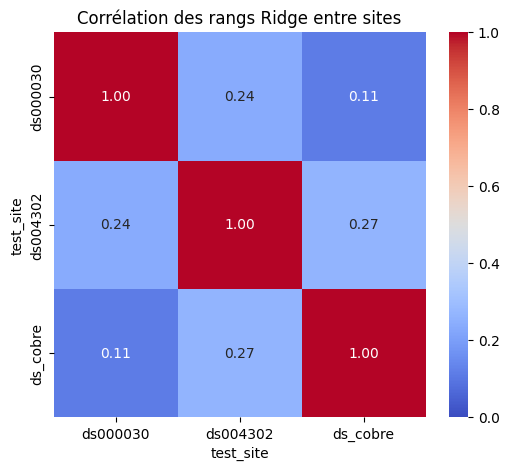


TOP 50 CONSENSUS RIDGE (Variables les mieux classées en moyenne)
test_site      avg_rank   std_rank  avg_weight_signed  ds000030  ds004302  ds_cobre
feature_name                                                                       
corr_309_344   51.66667   38.56020           -0.00092       2.0      96.0      57.0
corr_401_430   60.66667    2.86744           -0.00085      61.0      57.0      64.0
corr_390_426   66.33333   38.87015            0.00086      34.0     121.0      44.0
corr_401_434   68.00000   21.92411           -0.00085      37.0      84.0      83.0
corr_193_426   78.00000   38.49675            0.00086     120.0      87.0      27.0
corr_3_426    115.66667   82.80231            0.00084      23.0     100.0     224.0
corr_232_339  126.00000  109.33435            0.00086     271.0       7.0     100.0
corr_184_408  127.66667  161.72885           -0.00096     356.0       2.0      25.0
corr_224_227  137.33333  105.92555           -0.00081      57.0     287.0      68.0
corr_314_4

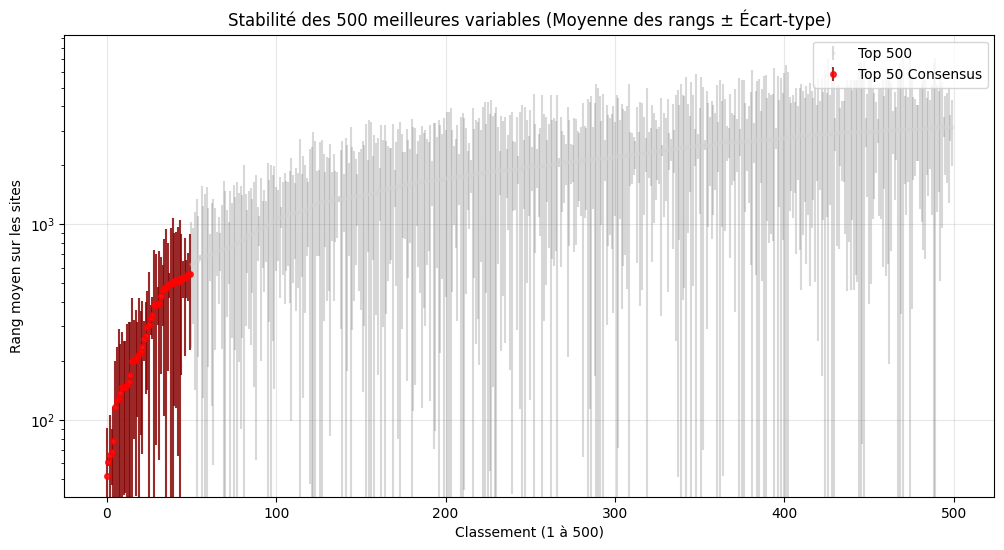

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# ============================================================
# CONFIGURATION & CHEMINS
# ============================================================
PATH_RIDGE = "../../results_loso_ridge_final/loso_features_weights.tsv"
ATLAS_TSV = "/scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.tsv"

# Configuration de l'affichage Pandas
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 5)  # 5 décimales pour les poids

# ============================================================
# 1. CHARGEMENT DES RÉSULTATS RIDGE
# ============================================================
print(f"Chargement des données Ridge : {PATH_RIDGE}")
df_ridge = pd.read_csv(PATH_RIDGE, sep='\t')

# ============================================================
# 2. CALCUL DES RANGS PAR SITE
# ============================================================
# On travaille sur la valeur absolue des poids (importance)
df_ridge['abs_weight'] = df_ridge['weight'].abs()

# Création du rang pour chaque site (method='min' : 1 = le plus important)
df_ridge['rank_site'] = df_ridge.groupby('test_site')['abs_weight'].rank(ascending=False, method='min')

# Pivot : Lignes=features, Colonnes=sites, Valeurs=rang
df_pivot_rank = df_ridge.pivot(index='feature_name', columns='test_site', values='rank_site')

print(f"Nombre de features analysées : {len(df_pivot_rank)}")
print(f"Sites disponibles : {list(df_pivot_rank.columns)}")

# ============================================================
# 3. CORRÉLATION DE RANG (Spearman)
# ============================================================
corr_matrix = df_pivot_rank.corr(method='spearman')

print("\n--- Corrélation de Spearman entre les classements des sites ---")
print(corr_matrix.round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f")
plt.title("Corrélation des rangs Ridge entre sites")
plt.show()

# ============================================================
# 4. IDENTIFICATION DU CONSENSUS
# ============================================================
# Calcul du rang moyen et de l'écart-type
df_pivot_rank['avg_rank'] = df_pivot_rank.mean(axis=1)
df_pivot_rank['std_rank'] = df_pivot_rank.std(axis=1)

# Récupération du poids moyen SIGNÉ (pour savoir si c'est positif/négatif)
df_pivot_weight = df_ridge.pivot(index='feature_name', columns='test_site', values='weight')
df_pivot_rank['avg_weight_signed'] = df_pivot_weight.mean(axis=1)

# Tri pour obtenir le Top Consensus
df_consensus = df_pivot_rank.sort_values('avg_rank')
top_50 = df_consensus.head(50)

# ============================================================
# 5. AFFICHAGE ET EXPORT DU TOP 50
# ============================================================
print("\n" + "="*80)
print("TOP 50 CONSENSUS RIDGE (Variables les mieux classées en moyenne)")
print("="*80)

# Colonnes à afficher
cols_to_show = ['avg_rank', 'std_rank', 'avg_weight_signed'] + list(df_pivot_rank.columns[:-3])

# Affichage avec précision (réglée plus haut à 5 décimales)
print(top_50[cols_to_show])

# Export
top_50.reset_index().to_csv("ridge_top50_consensus.tsv", sep='\t', index=False)
print("\nFichier exporté : ridge_top50_consensus.tsv")

# ============================================================
# 6. VISUALISATION STABILITÉ (SCATTER PLOT)
# ============================================================
plt.figure(figsize=(12, 6))

top_500 = df_consensus.head(500)

# Fond gris : Top 500
plt.errorbar(
    x=range(len(top_500)), 
    y=top_500['avg_rank'], 
    yerr=top_500['std_rank'], 
    fmt='o', color='lightgray', ecolor='gray', 
    alpha=0.3, markersize=2, label='Top 500'
)

# En rouge : Top 50
plt.errorbar(
    x=range(50), 
    y=top_50['avg_rank'], 
    yerr=top_50['std_rank'], 
    fmt='o', color='red', ecolor='darkred', 
    alpha=0.8, markersize=4, label='Top 50 Consensus'
)

plt.title("Stabilité des 500 meilleures variables (Moyenne des rangs ± Écart-type)")
plt.xlabel("Classement (1 à 500)")
plt.ylabel("Rang moyen sur les sites")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()



ANALYSE FINALE DES RÉSEAUX (AVEC FREESURFER & BUCKNER)
Mapping créé pour 434 régions.
Attention: 'top_consensus' n'est pas en mémoire. J'utilise df_pivot_rank.
Analyse des 100 meilleures connexions...

--- CLASSEMENT DES RÉSEAUX (NŒUDS IMPLIQUÉS) ---
       Network  Count
5       Visual     34
3   Cerebellum     30
4      Default     27
6       SomMot     26
0  SalVentAttn     22
1      Control     21
2  Subcortical     21
8     DorsAttn     11
7       Limbic      7
9      TempPar      1

--- TOP 15 DES INTERACTIONS ---
 Count        Net1        Net2
     9      Visual      Visual
     8  Cerebellum      Visual
     8  Cerebellum Subcortical
     7  Cerebellum     Default
     4     Control SalVentAttn
     4     Default      SomMot
     4     Default Subcortical
     4      SomMot      SomMot
     4 SalVentAttn SalVentAttn
     3     Control      SomMot
     3     Default     Default
     3 SalVentAttn      SomMot
     3     Control     Default
     3     Control     Control
     2  

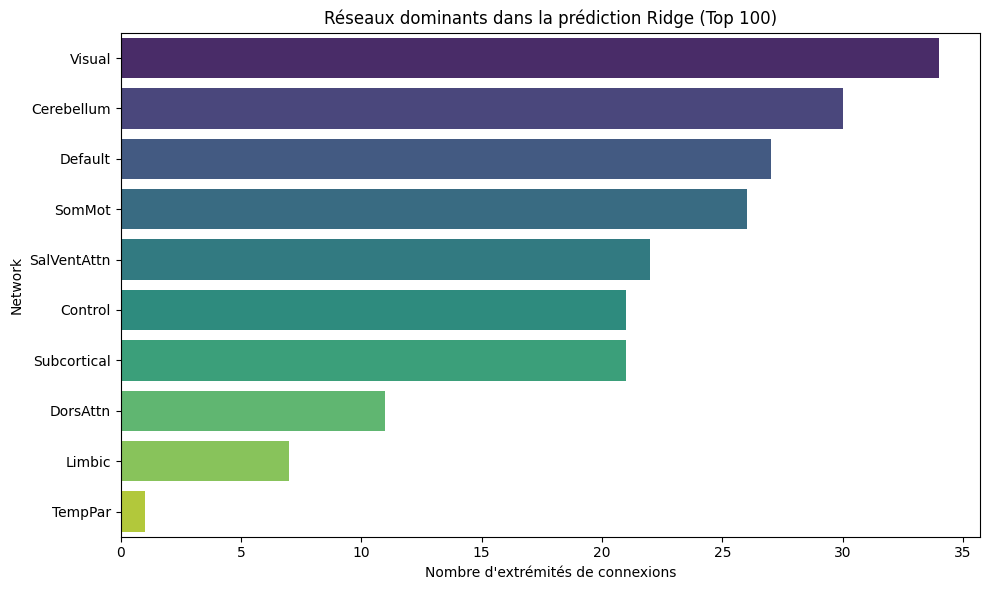

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ============================================================
# CONFIGURATION
# ============================================================
ATLAS_TSV = "/scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.tsv"

# ============================================================
# 1. FONCTION DE PARSING AVANCÉE (ADAPTÉE À TA LISTE)
# ============================================================
def get_network_name_precise(raw_name):
    s = str(raw_name).strip()
    
    # --- 1. SOUS-CORTICAL (FREESURFER) ---
    # Ex: FreeSurfer_Left-Thalamus-Proper
    if "FreeSurfer" in s:
        return "Subcortical"

    # --- 2. CERVELET (BUCKNER) ---
    # Ex: Buckner2011_17Networks_13
    if "Buckner" in s:
        return "Cerebellum"

    # --- 3. CORTEX (SCHAEFER) ---
    # Ex: Schaefer2018_17Networks_LH_VisCent_ExStr_1
    # On cherche le mot clé après LH_ ou RH_
    match = re.search(r'(?:LH|RH)_([A-Za-z]+)_', s)
    if match:
        # On nettoie un peu les variantes (ex: SomMotA -> SomMot)
        net = match.group(1)
        # Optionnel : regrouper A/B/C pour simplifier l'affichage
        if "SomMot" in net: return "SomMot"
        if "Vis" in net: return "Visual"
        if "DorsAttn" in net: return "DorsAttn"
        if "SalVentAttn" in net: return "SalVentAttn"
        if "Limbic" in net: return "Limbic"
        if "Cont" in net: return "Control"
        if "Default" in net: return "Default"
        if "TempPar" in net: return "TempPar"
        return net # Cas où ça ne matche pas les ifs
    
    return "Other"

# ============================================================
# 2. RECONSTRUCTION DU MAPPING
# ============================================================
print("\n" + "="*80)
print("ANALYSE FINALE DES RÉSEAUX (AVEC FREESURFER & BUCKNER)")
print("="*80)

try:
    # Lecture brute
    labels_df = pd.read_csv(ATLAS_TSV, sep='\t', header=None, dtype=str)
    
    # DÉTECTION INTELLIGENTE DE LA COLONNE
    # On cherche la colonne qui contient "FreeSurfer"
    target_col = -1
    for col in labels_df.columns:
        if labels_df[col].str.contains("FreeSurfer").any():
            target_col = col
            break
            
    if target_col == -1:
        print("ERREUR: Impossible de trouver les labels FreeSurfer dans le fichier.")
        # Fallback si l'utilisateur a collé la liste manuellement dans le code précédent
        # Mais ici on assume que le fichier est bon.
        exit()
        
    raw_labels = labels_df[target_col].tolist()
    
    # Mapping Index -> Réseau
    # Index 1-based pour matcher tes corr_x_y
    id_to_network = {i+1: get_network_name_precise(name) for i, name in enumerate(raw_labels)}
    
    print(f"Mapping créé pour {len(id_to_network)} régions.")

except Exception as e:
    print(f"Erreur lecture fichier: {e}")
    exit()

# ============================================================
# 3. ANALYSE DU TOP 100 (Avec interaction)
# ============================================================

if 'top_consensus' not in locals():
     # Fallback pour ne pas planter si tu copies juste ce bloc
     print("Attention: 'top_consensus' n'est pas en mémoire. J'utilise df_pivot_rank.")
     features_list = df_pivot_rank.sort_values('avg_rank').head(100).index.tolist()
else:
    features_list = top_consensus.head(100).index.tolist()

network_counts = {}
interaction_counts = {}

print(f"Analyse des {len(features_list)} meilleures connexions...")

for feature in features_list:
    try:
        parts = feature.split('_')
        idx_a, idx_b = int(parts[1]), int(parts[2])
        
        net_a = id_to_network.get(idx_a, "Unknown")
        net_b = id_to_network.get(idx_b, "Unknown")
        
        # Comptage individuel
        network_counts[net_a] = network_counts.get(net_a, 0) + 1
        network_counts[net_b] = network_counts.get(net_b, 0) + 1
        
        # Comptage interaction (A <-> B)
        pair = tuple(sorted([net_a, net_b]))
        interaction_counts[pair] = interaction_counts.get(pair, 0) + 1
        
    except:
        continue

# ============================================================
# 4. AFFICHAGE DES RÉSULTATS
# ============================================================

# A. Par Réseau (Histogramme)
df_res = pd.DataFrame(list(network_counts.items()), columns=['Network', 'Count'])
df_res = df_res.sort_values('Count', ascending=False)

print("\n--- CLASSEMENT DES RÉSEAUX (NŒUDS IMPLIQUÉS) ---")
print(df_res)

# B. Par Interaction (Qui parle à qui ?)
df_inter = pd.DataFrame(list(interaction_counts.items()), columns=['Pair', 'Count'])
# Séparer la paire pour affichage
df_inter['Net1'] = df_inter['Pair'].apply(lambda x: x[0])
df_inter['Net2'] = df_inter['Pair'].apply(lambda x: x[1])
df_inter = df_inter.sort_values('Count', ascending=False).drop(columns=['Pair'])

print("\n--- TOP 15 DES INTERACTIONS ---")
print(df_inter.head(15).to_string(index=False))

# Visualisation finale
plt.figure(figsize=(10, 6))
sns.barplot(data=df_res, x='Count', y='Network', hue='Network', legend=False, palette='viridis')
plt.title("Réseaux dominants dans la prédiction Ridge (Top 100)")
plt.xlabel("Nombre d'extrémités de connexions")
plt.tight_layout()
plt.show()


GÉNÉRATION DE LA HEATMAP D'INTERACTIONS


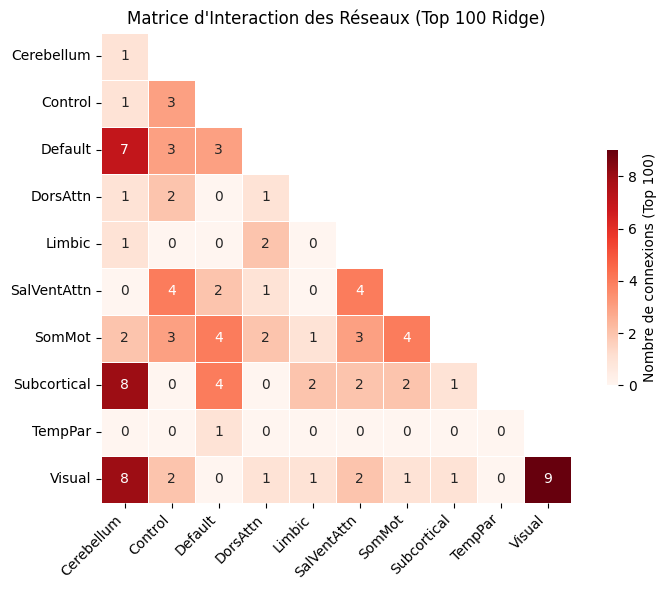

Interprétation du graphique :
- Les cases foncées montrent les paires de réseaux qui interagissent le plus.
- La diagonale représente les connexions internes à un même réseau.


In [12]:
import numpy as np

# ============================================================
# 5. VISUALISATION : MATRICE D'INTERACTION (HEATMAP)
# ============================================================
print("\n" + "="*80)
print("GÉNÉRATION DE LA HEATMAP D'INTERACTIONS")
print("="*80)

# 1. Préparation de la matrice
# On récupère tous les réseaux uniques identifiés dans le top 100
unique_nets = sorted(list(set([n for pair in interaction_counts.keys() for n in pair])))

# On crée une matrice vide (N x N)
interaction_matrix = pd.DataFrame(0, index=unique_nets, columns=unique_nets)

# On remplit la matrice (symétrique)
for (net_a, net_b), count in interaction_counts.items():
    interaction_matrix.loc[net_a, net_b] = count
    interaction_matrix.loc[net_b, net_a] = count # Symétrie

# 2. Affichage
plt.figure(figsize=(8, 6))

# Masque pour ne garder que le triangle inférieur (pour éviter les doublons visuels)
mask = np.triu(np.ones_like(interaction_matrix, dtype=bool), k=1)

sns.heatmap(
    interaction_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Reds', 
    mask=mask,
    linewidths=.5,
    square=True,
    cbar_kws={"shrink": .5, "label": "Nombre de connexions (Top 100)"}
)

plt.title("Matrice d'Interaction des Réseaux (Top 100 Ridge)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Interprétation du graphique :")
print("- Les cases foncées montrent les paires de réseaux qui interagissent le plus.")
print("- La diagonale représente les connexions internes à un même réseau.")

Chargement des poids Ridge...
Dimensions : (93096, 3) (Features x Sites)

--- Matrice de Corrélation de Pearson (Poids Bruts) ---
test_site  ds000030  ds004302  ds_cobre
test_site                              
ds000030    1.00000   0.58003   0.38840
ds004302    0.58003   1.00000   0.59798
ds_cobre    0.38840   0.59798   1.00000


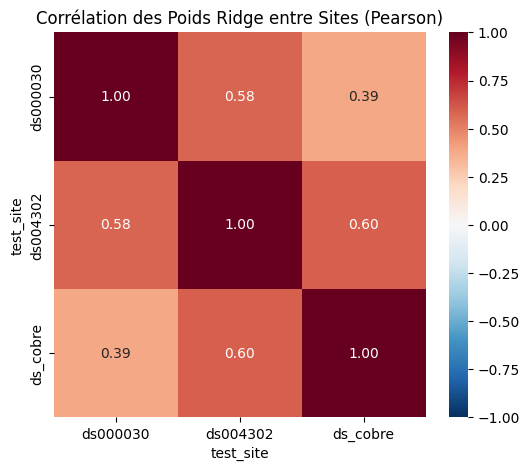

Génération des graphiques de comparaison...


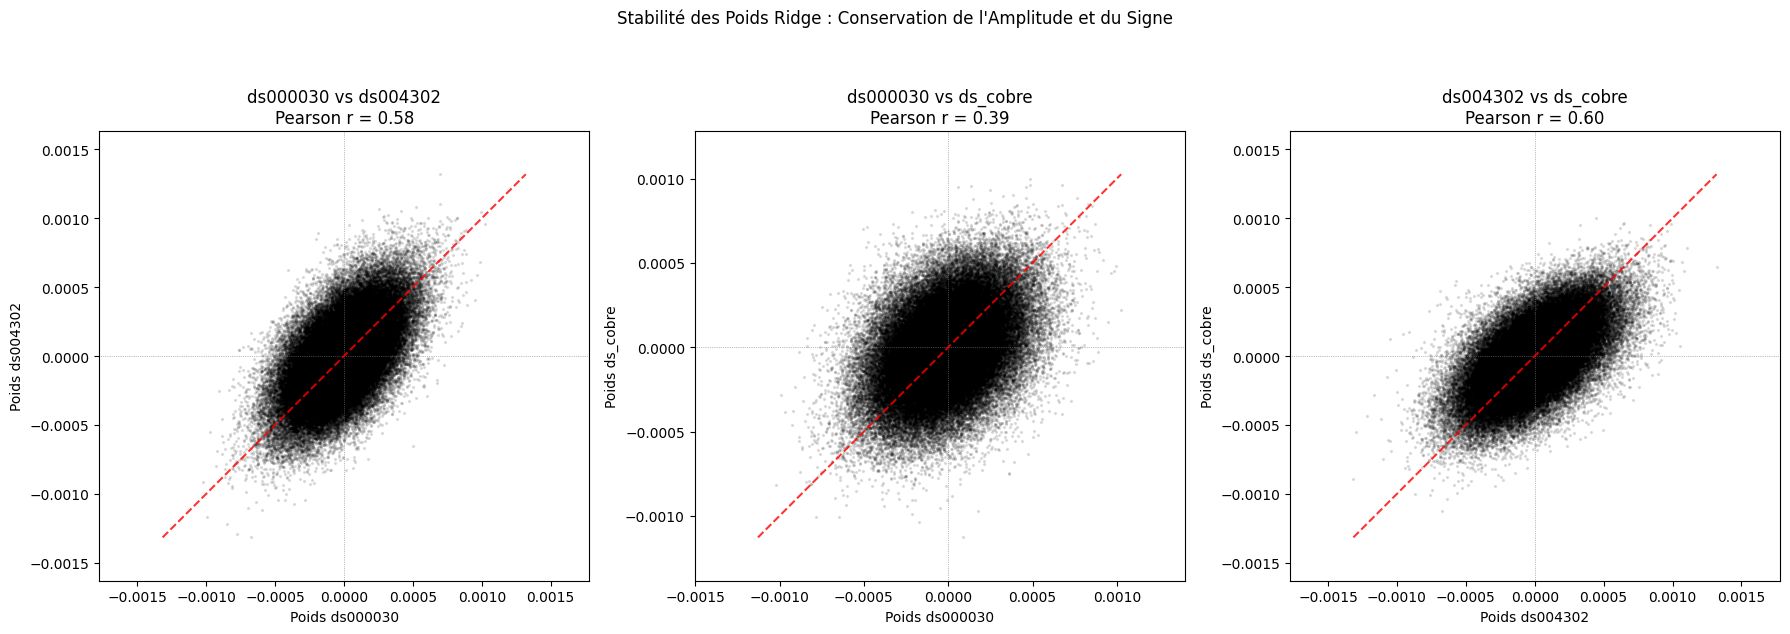


--- Concordance de Signe sur le Top 5% des connexions ---
Seuil d'importance (Top 5%) : |weight| > 0.0005
ds000030 vs ds004302 : 93.3% de concordance de signe (sur 8710 vars)
ds000030 vs ds_cobre : 82.3% de concordance de signe (sur 6789 vars)
ds004302 vs ds_cobre : 92.9% de concordance de signe (sur 9419 vars)


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ============================================================
# 1. CHARGEMENT
# ============================================================
path_ridge = "../../results_loso_ridge_final/loso_features_weights.tsv"
print("Chargement des poids Ridge...")
df_ridge = pd.read_csv(path_ridge, sep='\t')

# ============================================================
# 2. PRÉPARATION (PIVOT)
# ============================================================
# On garde les poids bruts (signés)
# Index = Feature, Colonnes = Sites, Valeurs = Poids
df_weights = df_ridge.pivot(index='feature_name', columns='test_site', values='weight')
sites = df_weights.columns.tolist()

print(f"Dimensions : {df_weights.shape} (Features x Sites)")

# ============================================================
# 3. MATRICE DE CORRÉLATION (PEARSON)
# ============================================================
# Pearson mesure la linéarité globale
corr_matrix = df_weights.corr(method='pearson')

print("\n--- Matrice de Corrélation de Pearson (Poids Bruts) ---")
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Corrélation des Poids Ridge entre Sites (Pearson)")
plt.show()

# ============================================================
# 4. SCATTER PLOTS (POIDS VS POIDS)
# ============================================================
print("Génération des graphiques de comparaison...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [(sites[0], sites[1]), (sites[0], sites[2]), (sites[1], sites[2])]

for i, (site_A, site_B) in enumerate(pairs):
    ax = axes[i]
    
    # Données
    x = df_weights[site_A]
    y = df_weights[site_B]
    
    # Corrélation spécifique
    r, p = pearsonr(x, y)
    
    # SCATTER PLOT
    # Alpha très bas car beaucoup de points
    ax.scatter(x, y, alpha=0.1, s=2, color='black', label='Connexions')
    
    # Esthétique : Lignes zéro
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.5)
    
    # Ligne d'identité (y=x) en rouge pour voir l'idéal
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Identité (y=x)')
    
    # Titres et labels
    ax.set_title(f"{site_A} vs {site_B}\nPearson r = {r:.2f}")
    ax.set_xlabel(f"Poids {site_A}")
    ax.set_ylabel(f"Poids {site_B}")
    
    # On force un ratio carré pour ne pas déformer la perception
    ax.set_aspect('equal', adjustable='datalim')

plt.suptitle("Stabilité des Poids Ridge : Conservation de l'Amplitude et du Signe", y=1.05)
plt.tight_layout()
plt.show()

# ============================================================
# 5. CONCORDANCE DE SIGNE (TOP FEATURES)
# ============================================================


print("\n--- Concordance de Signe sur le Top 5% des connexions ---")

# Seuil global (95ème percentile des valeurs absolues)
threshold = np.percentile(df_weights.abs().values.flatten(), 95)
print(f"Seuil d'importance (Top 5%) : |weight| > {threshold:.4f}")

for (site_A, site_B) in pairs:
    # On prend les connexions qui sont fortes dans AU MOINS un des deux sites
    mask_strong = (df_weights[site_A].abs() > threshold) | (df_weights[site_B].abs() > threshold)
    subset = df_weights.loc[mask_strong]
    
    # Vérification du signe
    same_sign = (np.sign(subset[site_A]) == np.sign(subset[site_B]))
    concordance = same_sign.mean() * 100
    
    print(f"{site_A} vs {site_B} : {concordance:.1f}% de concordance de signe (sur {len(subset)} vars)")